# TP – ACP (Analyse en Composantes Principales)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


df = pd.read_csv("winequality-red.csv")
print(df.head())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

# Préparation des données

In [3]:
X = df.select_dtypes(include=[np.number]).copy()
X = X.dropna()
feature_names = X.columns.tolist()
print(feature_names)
scaler = StandardScaler()
Z = scaler.fit_transform(X)

print(Z)

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
[[-0.52835961  0.96187667 -1.39147228 ... -0.57920652 -0.96024611
  -0.78782264]
 [-0.29854743  1.96744245 -1.39147228 ...  0.1289504  -0.58477711
  -0.78782264]
 [-0.29854743  1.29706527 -1.18607043 ... -0.04808883 -0.58477711
  -0.78782264]
 ...
 [-1.1603431  -0.09955388 -0.72391627 ...  0.54204194  0.54162988
   0.45084835]
 [-1.39015528  0.65462046 -0.77526673 ...  0.30598963 -0.20930812
  -0.78782264]
 [-1.33270223 -1.21684919  1.02199944 ...  0.01092425  0.54162988
   0.45084835]]


# Lancer l’ACP

In [7]:
pca = PCA() # calcule toutes les composantes
scores = pca.fit_transform(Z) # projections des individus (n × p)
eigvals = pca.explained_variance_ # ~ "valeurs propres"
ratio = pca.explained_variance_ratio_ # % de variance par composante
cum = ratio.cumsum()

# Courbe des éboulis (Scree plot)

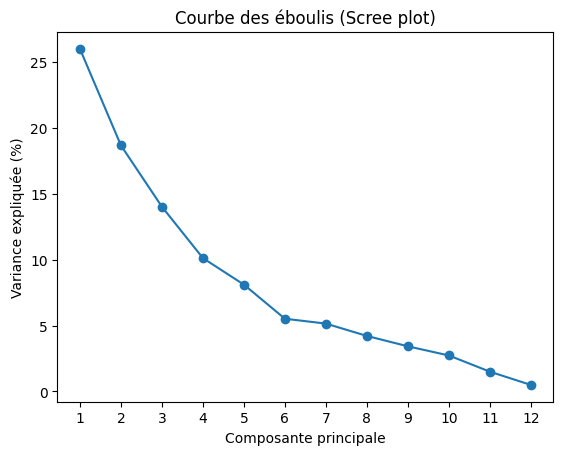

In [12]:
plt.figure()
plt.plot(range(1, len(ratio)+1), ratio*100, marker='o')
plt.xlabel("Composante principale"); plt.ylabel("Variance expliquée (%)")
plt.title("Courbe des éboulis (Scree plot)")
plt.xticks(range(1, len(ratio)+1))
plt.show()

**Observation sur la courbe des éboulis :**

On constate un ralentissement marqué de la variance expliquée à partir de la 4ᵉ composante principale.  
Ainsi, il semble pertinent de retenir les 4 premiers axes pour l’analyse, car ils capturent l’essentiel de l’information du jeu de données.


# Variance expliquée cumulée

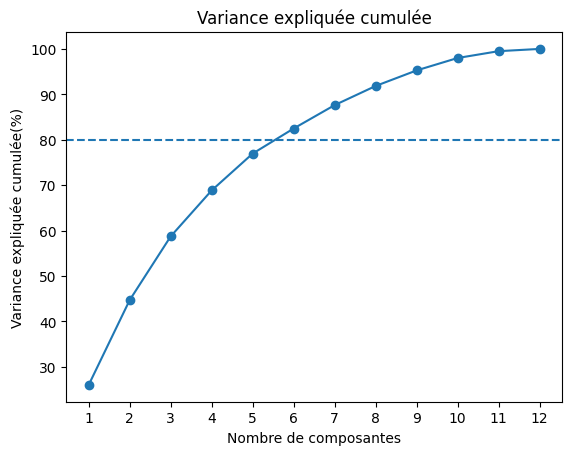

In [13]:
plt.figure()
plt.plot(range(1, len(cum)+1), cum*100, marker='o')
plt.axhline(80, linestyle='--') # exemple de seuil 80%
plt.xlabel("Nombre de composantes"); plt.ylabel("Variance expliquée cumulée(%)")
plt.title("Variance expliquée cumulée")
plt.xticks(range(1, len(cum)+1))
plt.show()

Le plus petit nombre de composantes principales \( K \) permettant d’atteindre au moins 80 % de la variance expliquée est **6**.

En effet, la valeur de `cum` (variance expliquée cumulée) dépasse 80 % à la 6ᵉ composante :
- \( \text{cum}[5] \approx 0.8247 \) soit 82.47 %

# Critère de Kaiser (sur corrélations ⇒ après standardisation)

In [14]:
# Matrice de corrélation (variables standardisées)
R = np.corrcoef(Z, rowvar=False)
# Valeurs propres de R (R symétrique → eigh)
eigvals_R, eigvecs_R = np.linalg.eigh(R)
eigvals_R = eigvals_R[::-1] # tri décroissant
print("Valeurs propres de R :", np.round(eigvals_R, 3))
print("Nb d'axes selon Kaiser (λ>1) :", (eigvals_R > 1.0).sum())

Valeurs propres de R : [3.121 2.242 1.683 1.215 0.973 0.663 0.618 0.506 0.411 0.328 0.18  0.06 ]
Nb d'axes selon Kaiser (λ>1) : 4


# Biplot (PC1 vs PC2)

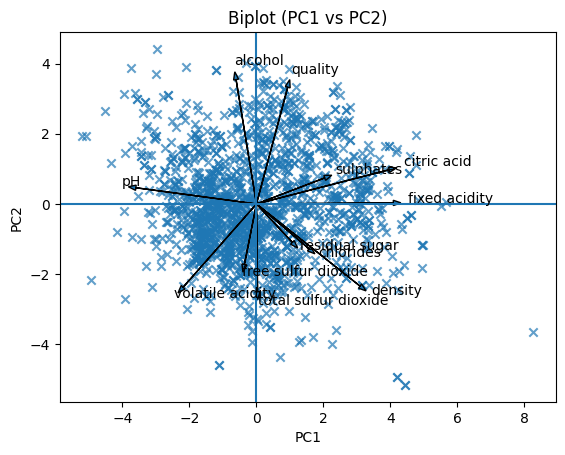

In [15]:
# Loadings = corr(variable, PC) pour données standardisées
loadings = pca.components_.T * np.sqrt(pca.explained_variance_) # (p, p)
def biplot(scores2d, loads2d, names):
    plt.figure()
    plt.scatter(scores2d[:,0], scores2d[:,1], alpha=0.7, marker='x')  # croix au lieu de points
    scale = 5.0
    for i, name in enumerate(names):
        x, y = loads2d[i,0]*scale, loads2d[i,1]*scale
        plt.arrow(0, 0, x, y, head_width=0.15, length_includes_head=True)
        plt.text(x*1.05, y*1.05, name)
    plt.axhline(0); plt.axvline(0)
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Biplot (PC1 vs PC2)")
    plt.show()
biplot(scores[:, :2], loadings[:, :2], feature_names)

Les variables ayant des flèches longues sur le biplot (PC1 vs PC2) sont celles dont la norme du vecteur de loadings sur les deux premiers axes est élevée.  
Dans ce jeu de données, il s’agit principalement de :

- **fixed acidity**
- **citric acid**
- **density**
- **volatile acidity**

Ces variables sont bien expliquées par les deux premières composantes principales et contribuent fortement à la structuration des données sur le plan PC1–PC2.

Les paires de variables qui semblent **corrélées** (flèches proches sur le biplot ou coefficients de corrélation élevés dans la matrice R) sont :


- **free sulfur dioxide** et **total sulfur dioxide** 
- **chlorides** et **density** 
- **chlorides** et **residual sugar** 
- **citric acid** et **sulfates** 
- **alcohol** et **quality** 
- **residual sugar** et **density** 

Les paires de variables qui semblent **opposées** (flèches en sens contraire ou corrélation négative forte) sont :

- **fixed acidity** et **pH** 
- **citric acid** et **volatile acidity** 
- **density** et **alcohol** 
- **volatile acidity** et **quality** 
- **fixed acidity** et **volatile acidity** 

Ces relations se retrouvent visuellement sur le biplot : les flèches proches indiquent une corrélation positive, tandis que les flèches opposées indiquent une corrélation négative.

# Cercle des corrélations (PC1 vs PC2)

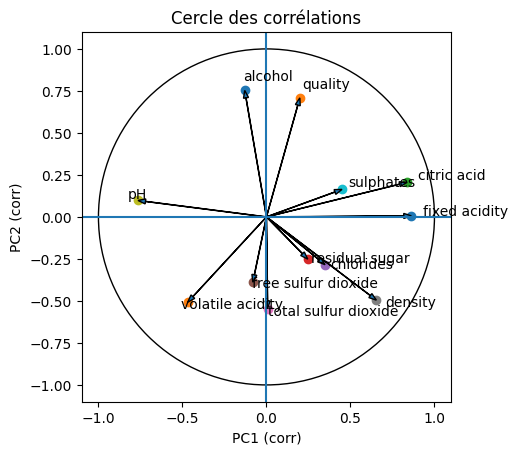

In [16]:
def correlation_circle(loads2d, names):
    plt.figure()
    ax = plt.gca()
    circle = plt.Circle((0,0), 1, fill=False)
    ax.add_artist(circle)
    for i, name in enumerate(names):
        x, y = loads2d[i,0], loads2d[i,1]
        plt.scatter(x, y)
        plt.arrow(0, 0, x, y, head_width=0.03, length_includes_head=True)
        plt.text(x*1.08, y*1.08, name)
    plt.axhline(0); plt.axvline(0)
    plt.xlim(-1.1, 1.1); plt.ylim(-1.1, 1.1); plt.gca().set_aspect("equal",
    "box")
    plt.xlabel("PC1 (corr)"); plt.ylabel("PC2 (corr)"); plt.title("Cercle des corrélations")
    plt.show()
correlation_circle(loadings[:, :2], feature_names)

# 1️⃣ Variables près du bord (fortement expliquées par PC1 et PC2)

Les flèches proches de la circonférence (longues) montrent une forte représentation sur les deux premiers axes :

Très fortes contributions :

fixed acidity 

quality 

alcohol 

volatile acidity 

density

total sulfur dioxide

citric acide

PH

Ces variables sont bien expliquées par PC1 et PC2.

Variables moins bien expliquées (courtes, près du centre) :

sulphates

free sulfur dioxide

residual sugar 

chlorides

→ Ces variables pourraient être mieux représentées par PC3 ou PC4.

# 2️⃣ Corrélations via les angles entre flèches

Flèches proches / même direction → corrélation positive :

alcohol et quality (angle petit → positivement corrélées)

total sulfur dioxide et free sulfur dioxide (quasiment alignées → forte corrélation positive)

Flèches opposées → corrélation négative :

volatile acidity et alcohol / quality (opposées → corrélations négatives)

Flèches à 90° → quasi indépendantes :

pH et alcohol (≈90° → corrélation faible)

citric acid et volatile acidity (≈90° → corrélation faible)

# 3️⃣ Variables mal expliquées (près du centre)

sulphates, residual sugar, free sulfur dioxide ,chlorides
→ Ces variables sont proches de (0,0), donc leurs variations ne sont pas bien représentées par PC1 et PC2.
→ Pour mieux comprendre leur structure, il faudra regarder PC3/PC4.

# Choisir K et refitter (optionnel, propre)

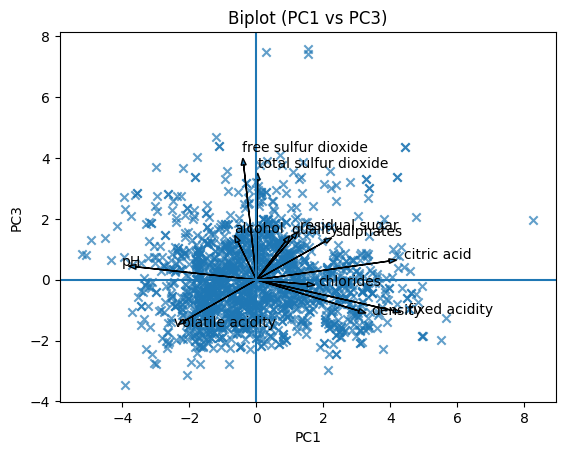

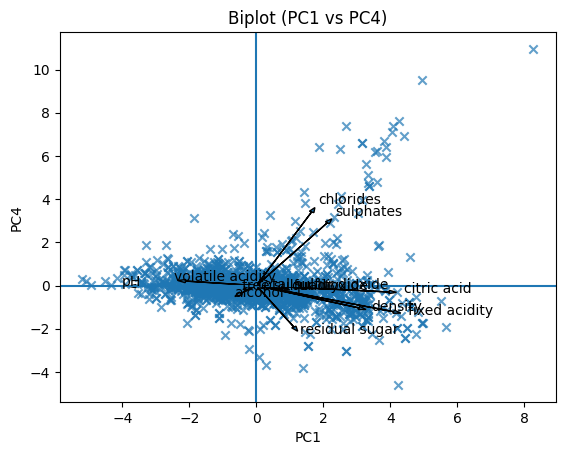

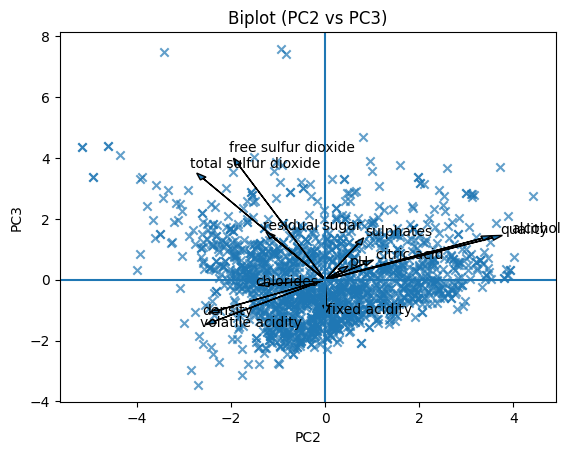

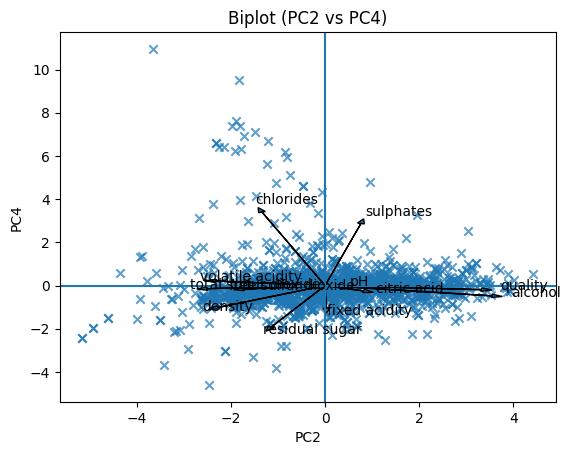

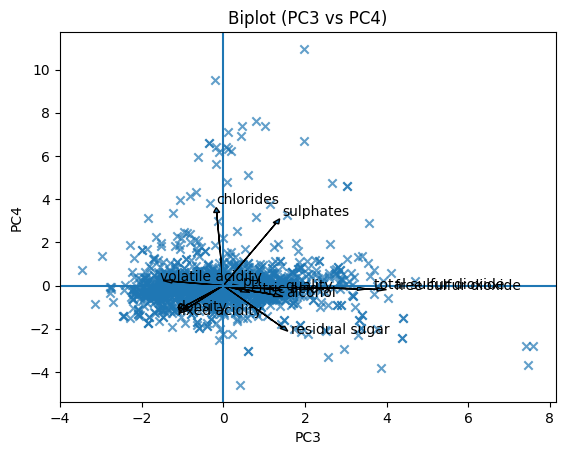

In [18]:
K = 4  # ou 4 selon votre analyse

# Refit PCA avec K composantes
pcaK = PCA(n_components=K)
scoresK = pcaK.fit_transform(Z)

def biplot(scores2d, loads2d, names, pcx=1, pcy=2):
    plt.figure()
    plt.scatter(scores2d[:, pcx-1], scores2d[:, pcy-1], alpha=0.7, marker='x')
    scale = 5.0
    for i, name in enumerate(names):
        x, y = loads2d[i, pcx-1]*scale, loads2d[i, pcy-1]*scale
        plt.arrow(0, 0, x, y, head_width=0.15, length_includes_head=True)
        plt.text(x*1.05, y*1.05, name)
    plt.axhline(0); plt.axvline(0)
    plt.xlabel(f"PC{pcx}")
    plt.ylabel(f"PC{pcy}")
    plt.title(f"Biplot (PC{pcx} vs PC{pcy})")
    plt.show()

# Utilisation pour différentes paires de composantes
biplot(scoresK, pcaK.components_.T * np.sqrt(pcaK.explained_variance_), feature_names, pcx=1, pcy=3)  # PC1 vs PC3
biplot(scoresK, pcaK.components_.T * np.sqrt(pcaK.explained_variance_), feature_names, pcx=1, pcy=4)  # PC1 vs PC4
biplot(scoresK, pcaK.components_.T * np.sqrt(pcaK.explained_variance_), feature_names, pcx=2, pcy=3)  # PC2 vs PC3
biplot(scoresK, pcaK.components_.T * np.sqrt(pcaK.explained_variance_), feature_names, pcx=2, pcy=4)  # PC2 vs PC4
biplot(scoresK, pcaK.components_.T * np.sqrt(pcaK.explained_variance_), feature_names, pcx=3, pcy=4)  # PC3 vs PC4